# SymPy: Calculus

In [2]:
import sys; sys.path.append('..')
from mlkit import np, sym, plt

## 1. SymPy
[SymPy] is a pure-Python library for symbolic math, designed for [symbolic computation]. This means expressions stay symbolic (exact), not numeric (approximate). SymPy can do this for all kinds of computations such as simplification, limits, derivatives and solving equations.

[SymPy]: https://github.com/sympy/sympy
[symbolic computation]: https://docs.sympy.org/latest/tutorials/intro-tutorial/intro.html#what-is-symbolic-computation

### 1.1. Expression
Expression is the most basic concept in Mathematics. We are going to use SymPy to create symbolic variables (distinguish them with Python variables), write expressions and substitute numbers to make evaluation.

In [3]:
# create some variables
x, y, z = sym.symbols('x,y,z')

In [4]:
# write an expression
expr = x**2 + 3*y + sym.cos(z)
expr

x**2 + 3*y + cos(z)

In [42]:
# substitute numbers, partially or fully
expr.subs({x: 2, y: 1})

cos(z) + 7

In [45]:
# by default, sympy will only evaluate non-decimal numbers once calling evalf()
sym.pi.evalf()

3.14159265358979

### 1.2. Simplification
[Simplification] is one of the most interesting parts in Mathematics. SymPy provides `simplify()`, a general but slow simplifier and a number of faster simplifiers dedicated to specific cases.

[Simplification]: https://docs.sympy.org/latest/tutorials/intro-tutorial/simplification.html#

In [ ]:
from mlkit import sym

In [2]:
x, y, z = sym.symbols('x:z')

In [3]:
lhs = sym.gamma(x) / sym.gamma(x-2)
rhs = lhs.simplify()
sym.Eq(lhs, rhs)

Eq(gamma(x)/gamma(x - 2), (x - 2)*(x - 1))

#### Polynomials
In polynomials, expansion and factorization are two opposite tasks, one prefers sum form of monomials and the other prefer product form of irreducible factors. Sometimes, we also want to collect monomials with the same degree.

In [4]:
lhs = (x+1) * (x+2) * (x+3)
rhs = lhs.expand()
sym.Eq(lhs, rhs)

Eq((x + 1)*(x + 2)*(x + 3), x**3 + 6*x**2 + 11*x + 6)

In [5]:
lhs = x**10 + x**2 + 1
rhs = lhs.factor()
sym.Eq(lhs, rhs)

Eq(x**10 + x**2 + 1, (x**2 - x + 1)*(x**2 + x + 1)*(x**6 - x**4 + 1))

In [6]:
lhs = x**2*z + 4*x*y*z + 4*y**2*z
rhs = lhs.factor()
sym.Eq(lhs, rhs)

Eq(x**2*z + 4*x*y*z + 4*y**2*z, z*(x + 2*y)**2)

In [7]:
lhs = x*y + x + 3 + 2*x**2 + z*x**2
rhs = lhs.collect(x)
sym.Eq(lhs, rhs)

Eq(x**2*z + 2*x**2 + x*y + x + 3, x**2*(z + 2) + x*(y + 1) + 3)

#### Trigonometric functions

In [8]:
expr = sym.sin(x)**2 + sym.cos(x)**2
result = expr.trigsimp()
sym.Eq(expr, result)

Eq(sin(x)**2 + cos(x)**2, 1)

In [10]:
expr = sym.sin(2*x)
result = sym.expand_trig(expr)
sym.Eq(expr, result)

Eq(sin(2*x), 2*sin(x)*cos(x))

#### Rewrite
A common way to deal with special functions is to *rewrite* them in terms of one another.

In [ ]:
expr = sym.tan(x)
result = expr.rewrite(sym.cos)
sym.Eq(expr, result)

Eq(tan(x), cos(x - pi/2)/cos(x))

In [25]:
lhs = sym.gamma(x)
rhs = lhs.rewrite(sym.factorial)
sym.Eq(lhs, rhs)

Eq(gamma(x), factorial(x - 1))

### 1.3. Solvers
A quick review of number sets in Mathematics: $\mathbb{N}$ (naturals), $\mathbb{Z}$ (integers), $\mathbb{Q}$ (rationals), $\mathbb{R}$ (reals) and $\mathbb{C}$ (complexes). They serve an important role of defining scope of the input.

In [ ]:
from mlkit import sym

In [3]:
x, y, z = sym.symbols('x:z')

#### Equation solver
The function [`solveset()`] solves an equation for one variable and returns a set of solutions. When an expression is passed in, it is automatically assumed to equal $0$. We can also change the equation domain to get appropriate solutions.

[`solveset()`]: https://docs.sympy.org/latest/modules/solvers/solveset.html

In [4]:
eq = sym.Eq(x**2, 1)
sym.solveset(eq, x)

{-1, 1}

In [5]:
sym.solveset('x^2 + 2*x + 5', x)

{-1 - 2*I, -1 + 2*I}

In [6]:
sym.solveset('x^2 + 2*x + 5', x, domain=sym.S.Reals)

EmptySet

#### Linear system solver
We can solve systems of equations by specifying each equation explicitly or using augumented matrix.

In [88]:
eq_sys = [
    sym.Eq(x + y + z, 6),
    sym.Eq(x + 2*y + z, 8),
    sym.Eq(x + y + 2*z, 9)
]

sym.linsolve(eq_sys, [x, y, z])

{(1, 2, 3)}

In [58]:
mat_agumented = sym.Matrix([
    [1, 1, 1, 6],
    [1, 2, 1, 8],
    [1, 1, 2, 9]
])

sym.linsolve(mat_agumented, (x, y, z))

#### Inequality solver
SymPy [solves inequalities] via a number of functions adapt to various cases.

[solves inequalities]: https://docs.sympy.org/latest/modules/solvers/inequalities.html

In [33]:
ineq = x**2 >= 4
sym.solve_univariate_inequality(ineq, x)

((2 <= x) & (x < oo)) | ((x <= -2) & (-oo < x))

## 2. Limits

### 2.1. Preview

In [ ]:
import sys; sys.path.append('..')
from mlkit import np, plt

#### The velocity problem
[Rate of change] or instantaneous [velocity] is an important concept in Data Science and Machine Learning. It is expressed as the [slope] $m$ of a line $y=mx+c$. However, in a non-linear function (which is very popular), the velocity changes as $x$ changes. To measure the instantaneous velocity at any given point, an visual approach is trying to draw a [tangent] then find its slope by computing $\Delta{y}/\Delta{x}$.

<br>

:::{image} ../image/chap_02/velocity_problem.png
:height: 180px
:align: center
:::
<br>

Let's an this example, we want to draw the tangent of the parabola at the blue point, $a$. It is the blue line, but we will have a hard time finding it. It would be more reasonable for us to approximate the tangent by drawing a [secant], like the red one.

$$m_a\approx\frac{f(x)-f(a)}{x-a}$$

We also observe that the orange secant is less accurate, as the orange $x$ is further from the $a$, compared to red $x$. In other words, we would want to move $x$ as close to $a$ as possible, but never let them overlap to make sure the secant can always be drawn. We say that $x$ approaches $a$, denoted $x\rightarrow a$. Such a process is mathematically written as:

$$m_a=\lim_{x\rightarrow a}\frac{f(x)-f(a)}{x-a}$$

[Rate of change]: https://en.wikipedia.org/wiki/Time_derivative
[velocity]: https://en.wikipedia.org/wiki/Velocity
[slope]: https://en.wikipedia.org/wiki/Slope
[tangent]: https://en.wikipedia.org/wiki/Tangent
[secant]: https://en.wikipedia.org/wiki/Secant_line

#### The area problem
Another popular problem in Calculus is evaluating the area under a curve over an interval. Same as the velocity problem, we cannot compute it exactly, but can try to approximate it.

<br>

:::{image} ../image/chap_02/area_problem.png
:height: 300px
:align: center
:::
<br>

One way to do this is dividing up the interval $[a,b]$ into $N$ small bins, each has a width of $h$ and is represented by a point $x_n$. This point is usually placed at the center or at one of the two boundaries of a bin. For each bin $n$, draw a rectangular having width of $h$ and height of $f(x_n)$. The area can be approximated by summing up the areas of all rectangulars:

$$S\approx\sum_{n=1}^{N}{hf(x_n)}$$

It's obvious that, the smaller $h$ is, the more accurate of our approximation. So we would want to reduce $h$ to be as close to $0$ as possible, but never equal to $0$ because at this point we cannot *draw* rectangulars. This is formally written as:

$$S=\lim_{h\rightarrow0}\sum_{n=1}^{N}{hf(x_n)}$$

### 2.2. Limits
[Limit] (of a function) is an essential building block in Calculus. This section will takes a deeper look at function limits to explain what limits are, but avoid the Mathematical definition. We also discuss of how to estimate them using SymPy instead of Mathematical approaches.

[Limit]: https://en.wikipedia.org/wiki/Limit_of_a_function

#### Cases of limit
:::{image} ../export/chap_02/limit_types.svg
:height: 250px
:align: center
:::
<br>

The images above show the behaviours of different functions around $x=2$. It summrizes most popular cases you may face when finding a limit:
- *Constant limits*. This is the easiest one to understand, shown in the first image. Even the function is not defined at $x=2$, it still has a limit:

$$\lim_{x\rightarrow2}\frac{x^2-4}{x-2}=4$$

- *One-sided limits*. In the second image, $y$ approaches different values when $x$ comes in different directions. The previous function in fact is a special case of one-sided limits, where limits of a function from both sides are equal. In this case:

$$\lim_{x\rightarrow2^-}\frac{|x-2|}{x-2}=-1;\qquad\lim_{x\rightarrow2^+}\frac{|x-2|}{x-2}=1$$

- *Infinite limits*. Limits are not constrained to be a number. If $f(x)$ increases or decrease without bound as $x\rightarrow a$, then the limit is said to be positive/negative infinite.

$$\lim_{x\rightarrow2}\frac{1}{(x-2)^2}=+\infty$$

- *Non-existent limits*. Sometimes, limits don't exist. For example, consider the function $y=\sin(x)$. When $x\rightarrow+\infty$, $y$ oscillates between $-1$ and $1$ and never converges. Limit in this case does not exist.

In [2]:
import sys; sys.path.append('..')
from mlkit import plt, np

fig, axs = plt.subplots(1, 3, sharey=True, figsize=(10,3))

for ax in axs:
    ax.spines['left'].set_position('zero')
    ax.spines['bottom'].set_position('zero')
    ax.spines['right'].set_color('none')
    ax.spines['top'].set_color('none')
    ax.set_xlim(-3, 6)
    ax.set_ylim(-2, 6)
    # ax.set_xticks([-2, -1, 1, 2, 3, 4, 5])
    # ax.set_yticks([-2, -1, 1, 2, 3, 4, 5])
    ax.set_xticklabels([]) # Hide labels to match image style
    ax.set_yticklabels([])
    # ax.grid(True, linestyle=':', alpha=0.6)
    ax.grid(False)
    ax.axis('equal')

# --- Plot 1: Removable Discontinuity (Hole) ---
# f(x) = (x^2 - 4) / (x - 2) simplifies to f(x) = x + 2 for x != 2
x1 = np.linspace(-3, 6, 400)
y1 = (x1**2 - 4) / (x1 - 2)
# We mask the exact point where it's undefined to avoid plotting issues
y1[np.isclose(x1, 2)] = np.nan

axs[0].plot(x1, y1, color='royalblue', linewidth=2)
axs[0].plot(2, 4, 'o', markerfacecolor='royalblue', markersize=10)
axs[0].plot(2, 4, 'o', markerfacecolor='white', markersize=6)
axs[0].set_title(r'$f(x) = \dfrac{x^2 - 4}{x - 2}$', y=-0.2)

# --- Plot 2: Jump Discontinuity ---
# g(x) = |x - 2| / (x - 2)
x2_left = np.linspace(-3, 1.95, 200)
x2_right = np.linspace(2.05, 6, 200)
y2_left = np.abs(x2_left - 2) / (x2_left - 2)
y2_right = np.abs(x2_right - 2) / (x2_right - 2)

axs[1].plot(x2_left, y2_left, color='royalblue', linewidth=2)
axs[1].plot(x2_right, y2_right, color='royalblue', linewidth=2)
axs[1].plot(2, -1, 'o', markerfacecolor='royalblue', markersize=10)
axs[1].plot(2, -1, 'o', markerfacecolor='white', markersize=6)
axs[1].plot(2, 1, 'o', markerfacecolor='royalblue', markersize=10)
axs[1].plot(2, 1, 'o', markerfacecolor='white', markersize=6)
axs[1].set_title(r'$g(x) = \dfrac{|x - 2|}{x - 2}$', y=-0.2, fontsize=12)

# --- Plot 3: Infinite Discontinuity (Asymptote) ---
# h(x) = 1 / (x - 2)^2
x3_left = np.linspace(-3, 1.85, 200)
x3_right = np.linspace(2.15, 6, 200)
y3_left = 1 / (x3_left - 2)**2
y3_right = 1 / (x3_right - 2)**2

axs[2].plot(x3_left, y3_left, color='royalblue', linewidth=2)
axs[2].plot(x3_right, y3_right, color='royalblue', linewidth=2)
axs[2].set_title(r'$h(x) = \dfrac{1}{(x - 2)^2}$', y=-0.2)

fig.savefig('../export/chap_02/limit_types.svg', dpi=500, bbox_inches='tight')
plt.close(fig)

#### Limits evaluation
Limits can be evaluated by looking at graphs or by constructing tables of function values. For more complex function, we cannot rely on these methods. Using a number of basic laws, here are some techniques we can use to evaluate limits: direct substitution, factorization, rationalization, conjugate multiplication, [L'Hospital's rule] and [squeeze theorem].

However, this topic is not a Calculus textbook, so instead of diving into these techniques, we are going to use SymPy. It provides us the function `limit()` evaluates the limit and the `Limit` class to store the unevaluated expression. Both take following arguments, in that order:
- The function you want to evaluate limit
- The variable in the limit
- The value which the variable tends towards
- The direction of the limit

[L'Hospital's rule]: https://en.wikipedia.org/wiki/L%27H%C3%B4pital%27s_rule
[squeeze theorem]: https://en.wikipedia.org/wiki/Squeeze_theorem

In [1]:
import sys; sys.path.append('..')
from mlkit import sym

In [35]:
x = sym.Symbol('x')
y = (x**2 - 4) / (x -2)

lim = sym.Limit(y, x, 2, dir='+-')
sym.Eq(lim, lim.doit())

Eq(Limit((x**2 - 4)/(x - 2), x, 2, dir='+-'), 4)

In [44]:
x = sym.Symbol('x')
y = 1 / (x -2)**2

lim = sym.Limit(y, x, 2, dir='+-')
sym.Eq(lim, lim.doit())

Eq(Limit((x - 2)**(-2), x, 2, dir='+-'), oo)

In [17]:
x = sym.Symbol('x')
y = sym.sin(1/x)

y.limit(x, 0, '+')

AccumBounds(-1, 1)

#### Euler's number
Imagine you are lending $1$ dollar at the [compound interest] rate of $100\%$ a year. How much money will you have after a year, if the compounding frequency $n$ keeps increasing? This problem leads directly to the definition of the [Euler's number], $e$:

$$e=\lim_{n\rightarrow\infty}\left(1+\frac{1}{n}\right)^n$$

Euler's number is one of the most important concepts in Mathematics and Calculus.

[Euler's number]: <https://en.wikipedia.org/wiki/E_(mathematical_constant)>
[compound interest]: https://en.wikipedia.org/wiki/Compound_interest

## 3. Derivatives
The [derivative] of a function $f$ is a function $f'$ describes velocities at different points. The process of finding a derivative is called [differentiation]. In Data Science, the most recognizable application of Differential Calculus is solving optimization problems.

[derivative]: https://en.wikipedia.org/wiki/Derivative
[differentiation]: https://en.wikipedia.org/wiki/Differential_calculus

### 3.1. Definition
Let's $y=f(x)$ be a function. The *derivative function*, denoted $f'(x)$, is a set of points that the following limit exists:

$$f'(x)=\frac{dy}{dx}=\lim_{\Delta{x}\rightarrow0}\frac{f(x+\Delta{x})-f(x)}{\Delta{x}} $$

Using this definition, we can find the derivatives of basic functions, for example:

$$\begin{aligned}
\frac{d}{dx}x^2
&= \lim_{h\rightarrow0}\frac{(x+h)^2-x^2}{h} \\
&= \lim_{h\rightarrow0}\frac{2hx+h^2}{h} \\
&= \lim_{h\rightarrow0}(2x+h) \\
&= 2x \\
\end{aligned}$$

#### Leibniz's notation
The expression $dy/dx$, [Leibniz's notation](https://en.wikipedia.org/wiki/Leibniz's_notation), is a more versatile way to write derivatives and is highly recommended. Here is how we write higher order derivatives:

$$
f''(x)=\frac{d^2}{dx^2}f(x);\qquad f'''(x)=f^{(3)}=\frac{d^3}{dx^3}f(x)
$$

### 3.2. Differentiability
Sometimes, derivatives at some points of a function $f$ cannot be evaluated, such a function is said to be non-[differentiable]. This happens when there is at least one point $x=a$ the derivative does not exist. Here are some common cases:
- $f$ is not [continuous] at $a$ over its [domain].
- $f$ is continuous but is not [smooth] at $a$. Formally, the limits differ when $x$ approaches $a$ from two sides. Example: $f(x)=|x|$ at $x=0$.
- $f$ has an infinite limit at $a$. In other words, the tangent at $a$ is a vertical line. Example: $f(x)=\sqrt[3]{x}$ at $x=0$.
- The limit at $a$ of $f$ does not exist. For example: $f(x)=\sin(1/x)$ at $x=0$.

[differentiable]: https://en.wikipedia.org/wiki/Differentiable_function
[continuous]: https://en.wikipedia.org/wiki/Continuous_function
[domain]: https://en.wikipedia.org/wiki/Domain_of_a_function
[smooth]: https://en.wikipedia.org/wiki/Smoothness

In [1]:
import sys; sys.path.append('..')
from mlkit import np, plt, sym

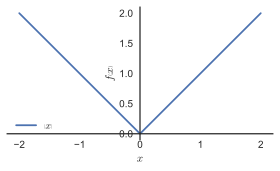

In [2]:
x, y, z = sym.symbols('x,y,z')
expr = sym.Abs(x)
label = f'${sym.latex(expr)}$'

with plt.style.context('seaborn-v0_8-white'):
    sym.plot(
        expr, (x, -2, 2),
        show=True, aspect_ratio=(1,1), legend=True, size=(4,4), label=label
    )

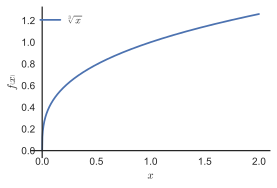

In [3]:
x, y, z = sym.symbols('x,y,z')
expr = sym.cbrt(x)
label = f'${sym.latex(expr)}$'

with plt.style.context('seaborn-v0_8-white'):
    sym.plot(
        expr, (x, 0, 2),
        show=True, aspect_ratio=(1,1), legend=True, size=(4,4), label=[label]
    )

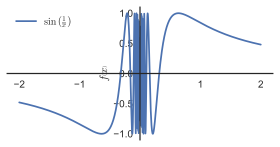

In [5]:
x, y, z = sym.symbols('x,y,z')
expr = sym.sin(1/x)
label = f'${sym.latex(expr)}$'

with plt.style.context('seaborn-v0_8-white'):
    sym.plot(
        expr, (x, -2, 2),
        show=True, aspect_ratio=(1,1), legend=True, size=(4,4), label=label
    )

### 3.3. Multivariate derivatives
We consider $f:\mathbb{R}^n\mapsto\mathbb{R}$, a function with multi-dimensional input and scalar output.

#### Partial derivative
[Partial derivative] is a concept defined for [multivariate functions], it is the derivative of the function with respect to each variable with the others held constant. For instance, the partial derivatives of $y=f(x_1,x_2)=x_1^2+\log{x_2}+x_1x_2$ are:

$$\begin{aligned}
\frac{\partial{y}}{\partial{x_1}} &= 2x_1+x_2 \\
\frac{\partial{y}}{\partial{x_2}} &= \frac{1}{x_2}+x_1
\end{aligned}$$

[Partial derivative]: https://en.wikipedia.org/wiki/Partial_derivative
[multivariate functions]: https://en.wikipedia.org/wiki/Function_of_several_real_variables

#### Gradient
The partial derivative reppresents the rate of change in a specific direction. If we use a column vector $\mathbf{x}$ to denote the input, then the set of all partial derivatives of $y=f(\mathbf{x})$ is called the [gradient], denoted $\nabla{y}$. The gradient is also written as a column vector, thus it has the same size with the input vector.

$$\mathbf{g}_f = \nabla{y} = \begin{bmatrix}
\dfrac{\partial{y}}{\partial{x_1}} &
\dfrac{\partial{y}}{\partial{x_2}} &
\dots &
\dfrac{\partial{y}}{\partial{x_n}}
\end{bmatrix}^\top$$

[gradient]: https://en.wikipedia.org/wiki/Gradient

:::{note}
In the case of vector-valued functions, partial derivatives are stored as a [Jacobian matrix]. This term is a generalization of the gradient for systems with multiple outputs.
:::

[Jacobian matrix]: https://en.wikipedia.org/wiki/Jacobian_matrix_and_determinant

#### Hessian
Becasue this is the most popular case in [matrix calculus] (scalar-by-vector derivatives), we are moving to a more complicated concept: second-order derivatives. It is written as a matrix, called the [Hessian matrix] as follows:

$$\mathbf{H}_f = \nabla^2 y = \begin{bmatrix} 
\dfrac{\partial^2 f}{\partial x_1^2} & \dfrac{\partial^2 f}{\partial x_1 \partial x_2} & \cdots & \dfrac{\partial^2 f}{\partial x_1 \partial x_n} \\ 
\dfrac{\partial^2 f}{\partial x_2 \partial x_1} & \dfrac{\partial^2 f}{\partial x_2^2} & \cdots & \dfrac{\partial^2 f}{\partial x_2 \partial x_n} \\ 
\vdots & \vdots & \ddots & \vdots \\ 
\dfrac{\partial^2 f}{\partial x_n \partial x_1} & \dfrac{\partial^2 f}{\partial x_n \partial x_2} & \cdots & \dfrac{\partial^2 f}{\partial x_n^2} 
\end{bmatrix}$$

[matrix calculus]: https://en.wikipedia.org/wiki/Matrix_calculus
[Hessian matrix]: https://en.wikipedia.org/wiki/Hessian_matrix

### 3.4. Derivatives evaluation

#### Basic derivatives
These basic derivatives are found easily using the definition.
- Constants: $c'=0$
- Power functions: $(x^n)'=nx^{n-1}$
- Exponential functions: $(a^x)'=a^x\log{a}$
- Logarithm functions: $(\log_ax)'=(x\log{a})^{-1}$
- Trigonometric functions: $\sin'{x}=\cos{x},\;\cos'{x}=-\sin{x},\;\tan'{x}=1+\tan^2x$

#### Derivative rules
- Sum rule: $(f+g)'=f'+g'$
- Product rule: $(fg)'=f'g+fg'$
- Chain rule: $\dfrac{dz}{dx}=\dfrac{dz}{dy}\dfrac{dy}{dx}$

#### Basic gradients
- Linear function: $\nabla(\mathbf{a}^T\mathbf{x})=\mathbf{a}$
- L2 norm squared: $\nabla(\mathbf{x}^T\mathbf{x})=2\mathbf{x}$
- Quadratic function: $\nabla(\mathbf{x}^T\mathbf{Ax})=(\mathbf{A}+\mathbf{A}^T)\mathbf{x}$
- Least Squares function: $\nabla\|\mathbf{Ax+b}\|_2^2=2\mathbf{A}^T(\mathbf{Ax+b})$

#### Implementation

:::{admonition} Case
:class: tip

Given the function $y=\log(x^2)$. Find the derivative of $y$ at $x=1$ using derivative rules and check it again with SymPy.

Let $y=f(u)=\log(u)$ and $u=g(x)=x^2$. Using the chain rule:

$$\frac{dy}{dx} = \frac{dy}{du}\cdot\frac{du}{dx} = \frac{1}{u}\cdot2x = \frac{2x}{x^2} = \frac{2}{x}$$

So, at $x=1$, the rate of change of $y$ with respect to $x$ is $2$.
:::

In [4]:
import sys; sys.path.append('..')
from mlkit import sym

In [4]:
x, y, z = sym.symbols('x:z')

In [18]:
expr = sym.log(x**2)
lhs = sym.Derivative(expr)
rhs = expr.diff()
sym.Eq(lhs, rhs)

Eq(Derivative(log(x**2), x), 2/x)

In [40]:
rhs.subs({x: 1})

2

### 3.5. Important theorems

#### Mean value theorem
[Mean value theorem] states that there is always some $c$ between $x_1,x_2$ such that:

$$f(x_1)-f(x_2)=f'(c)(x_1-x_2)$$

[Mean value theorem]: https://en.wikipedia.org/wiki/Mean_value_theorem

#### Taylor series
Sometimes, we need to solve a [differential equation], in which both a function and its derivatives exist. One way to solve this kind of function is using [Taylor series], an approximation of the function $f(x)$ using derivatives around a specific point $a$:

$$\begin{aligned}
f(x)
&= \lim_{N\rightarrow\infty}\sum_{n=0}^{N}\frac{f^{(n)}(a)}{n!}(x-a)^n \\
&= f(a)+f'(a)(x-a)+\frac{f''(a)}{2!}(x-a)^2+\dots
\end{aligned}$$

$N$ is called the order of the Taylor series. The higher $N$ is, the more accurate the approximation is.

[differential equation]: https://en.wikipedia.org/wiki/Differential_equation
[Taylor series]: https://en.wikipedia.org/wiki/Taylor_series

## 4. Integrals
The [integral] of a function $f$ is a function $F$ describes areas under the curve up to different points. The process of finding an integral is called [integration]. In Data Science, the most recognizable application of Integral Calculus is defining probabilities.

[integral]: https://en.wikipedia.org/wiki/Antiderivative
[integration]: https://en.wikipedia.org/wiki/Integral

### 4.1. Definition
The problem of area under the curve examined when we start learning about limits gives us the definition of *definite integral*. The term *area* here is loosely understood, as it can be negative when the curve is under the $x$-axis. It is defined within an interval $[a,b]$ given by:

$$\int_a^bf(x)dx=\lim_{\Delta{x}\rightarrow0}\sum_{n=1}^{N}{f(x_n)\Delta{x}}$$

The term $dx$ refers to a very small $\Delta{x}$ is called an [infinitesimal]. When using integral as a function, we use the concept *finite integral* or [anti-derivative] written as a function $F$ where $F'(x)=f(x)$. This is a more general concept as we can use it to compute definite integral:

$$\int_a^bf(x)dx=F(b)-F(a)$$

Notice that if $F'(x)=f(x)$ then $(F(x)+c)'=f(x)$ for any constant $c$. So basically there are a countless number of anti-derivatives, but they are all related. For simplicity, we only write $F(x)$.

[infinitesimal]: https://en.wikipedia.org/wiki/Infinitesimal
[anti-derivative]: https://en.wikipedia.org/wiki/Antiderivative

### 4.2. Integration rules
This section summarizes most popular anti-derivatives.
- Constant: $\displaystyle{\int cdx=cx}$

- Power functions: $\displaystyle{\int x^ndx=\dfrac{x^{n+1}}{n+1}}$

- Exponential functions: $\displaystyle{\int a^xdx=\frac{a^x}{\log a}}$

- Trigonometric functions:
$\displaystyle{
    \int\sin(x)dx=-\cos{x},\;
    \int\cos(x)dx=\sin{x},\;
    \int\tan(x)dx=-\log|\cos(x)|
}$

### 4.3. Implementation

In [ ]:
import sys; sys.path.append('..')
from mlkit import sym

In [1]:
x, y, z = sym.symbols('x:z')

In [7]:
x, y, z = sym.symbols('x:z')
y = sym.log(x)
y.integrate()

x*log(x) - x

In [12]:
x, y, z = sym.symbols('x:z')
z = 3**x + y**2
z.integrate((x, 1, 2), (y, 4, 5)).evalf()

25.7947686930944

## Resources
- openstax.com - [Calculus Volume 1](https://openstax.org/books/calculus-volume-1/pages/1-introduction)
- openstax.com - [Calculus Volume 2](https://openstax.org/books/calculus-volume-2/pages/1-introduction)
- openstax.com - [Calculus Volume 3](https://openstax.org/books/calculus-volume-3/pages/1-introduction)
- rodrigopacios.github.io - [Thomas' Calculus](https://rodrigopacios.github.io/mrpacios/download/Thomas_Calculus.pdf)
- cs.ubc.ca - [Deriving the Gradient of Linear and Quadratic Functions in Matrix Notation](https://www.cs.ubc.ca/~schmidtm/Courses/340-F16/linearQuadraticGradients.pdf)
- quora.com - [Can you explain Lagrange Multipliers without using any mathematical notation?](https://qr.ae/pvxTdc) 
- cornell.edu - [Duality](https://optimization.cbe.cornell.edu/index.php?title=Duality)
- cornell.edu - [Lagrangean duality](https://optimization.cbe.cornell.edu/index.php?title=Lagrangean_duality)
- ucdenver.edu - [Lagranrian duality](http://math.ucdenver.edu/~sborgwardt/wiki/index.php/Lagrangian_Duality)
- medium.com - [Optimization stories: KKT conditions](https://towardsdatascience.com/optimization-stories-kkt-conditions-f86aea4fb6c2)
- utoronto.ca - [Interpretation of Lagrange multipliers](https://mjo.osborne.economics.utoronto.ca/index.php/tutorial/index/1/ilm/t)
- northwestern.edu - [Lagrangean duality](https://optimization.mccormick.northwestern.edu/index.php/Lagrangean_duality)